In [22]:
import tsfresh as tsf
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.otlLib.optimize.gpos import Cluster

In [19]:
df = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Handmade_Log2_FC_from_FGZC_log2FC0.5_nRep0_allPhosphoFound_True.xlsx")
df

,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF1,EGF2,EGF5,EGF10,EGF90,...,INS5_std,INS10_std,INS90_std,EGFnINS_full_std,EGFnINS_starve_std,EGFnINS1_std,EGFnINS2_std,EGFnINS5_std,EGFnINS10_std,EGFnINS90_std
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.750617,0,-0.075632,0.051413,0.553841,1.071310,0.614675,...,0.132813,0.082451,0.158647,0.240242,0.073607,0.213038,0.017743,0.137722,0.158750,0.203929
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,-0.726273,0,-0.103509,-0.389250,-0.566986,-0.520466,-0.750087,...,0.096032,0.092438,0.135065,0.190606,0.107901,0.087274,0.362086,0.085434,0.223696,0.084909
2,A0AVK6,E2F8,A0AVK6_660_664_1_1_S664~ENSSALsPNHR,-0.053965,0,-0.055564,-0.459914,-0.356172,-0.444423,-0.573204,...,0.044172,0.235586,0.347732,0.055253,0.015215,0.234871,0.148124,0.019416,0.167992,0.144247
3,A0FGR8,ESYT2,A0FGR8_736_748_1_1_S739~SSSsLLASPGHISVK,1.471331,0,1.676516,0.067826,0.366299,-0.140682,0.055614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A0FGR8,ESYT2,A0FGR8_736_748_1_1_S743~SSSSLLAsPGHISVK,0.197225,0,-0.073658,-0.266355,-0.434298,-0.500583,-0.091087,...,0.340014,0.291000,0.414456,0.357400,0.564312,0.836518,0.274693,0.579285,0.540069,0.643002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7059,Q9Y6X9,MORC2,Q9Y6X9_723_735_1_1_S725~KTEsPIKLSPATPSR,-0.319801,0,0.090892,-0.215619,-0.159935,-0.098344,-0.378652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7060,Q9Y6X9,MORC2,Q9Y6X9_723_735_2_2_S725S730~KTEsPIKLsPATPSR,-0.104364,0,-0.032278,-0.134237,-0.239501,-0.081470,-0.507507,...,0.009456,0.079574,0.075932,0.010742,0.125325,0.095246,0.307339,0.045301,0.359092,0.041603
7061,Q9Y6X9,MORC2,Q9Y6X9_739_743_1_1_S743~SVAVsDEEEVEEEAERR,-0.411413,0,-0.013029,-0.037583,-0.683015,-1.073718,-0.181425,...,0.119793,0.184561,0.132265,0.028969,0.122729,0.181125,0.055988,0.194354,0.210178,0.119344
7062,Q9Y6X9,MORC2,Q9Y6X9_739_743_2_2_S739S743~sVAVsDEEEVEEEAER,1.060594,0,-0.010913,0.251570,1.726090,2.320177,0.937512,...,0.189913,0.207445,0.178301,0.091927,0.317889,0.384452,0.211207,0.254863,0.307187,0.130371


In [27]:
columns = ["id", "time", "EGF", "INS", "EGFnINS"]
conditions_dic = {"-120":["EGF_full", "INS_full", "EGFnINS_full"],
                  "0" : ["EGF_starve", "INS_starve", "EGFnINS_starve"],
                  "1" : ["EGF1", "INS1", "EGFnINS1"],
                  "2" : ["EGF2", "INS2", "EGFnINS2"],
                  "5" : ["EGF5", "INS5", "EGFnINS5"],
                  "10" : ["EGF10", "INS10", "EGFnINS10"],
                  "90" : ["EGF90", "INS90", "EGFnINS90"]}
tsfresh_df = pd.DataFrame(columns=columns)
for idx, row in df.iterrows():
    for key in conditions_dic.keys():
        append = [row["site"], key, row[conditions_dic[key][0]], row[conditions_dic[key][1]], row[conditions_dic[key][2]]]
        tsfresh_df.loc[len(tsfresh_df)] = append
        
tsfresh_df.to_excel("Experiment/1_hTERT_HME1/Data/Processed/multivariate_Handmade_Log2_FC_from_FGZC_log2FC0.5_nRep0_allPhosphoFound_True.xlsx")

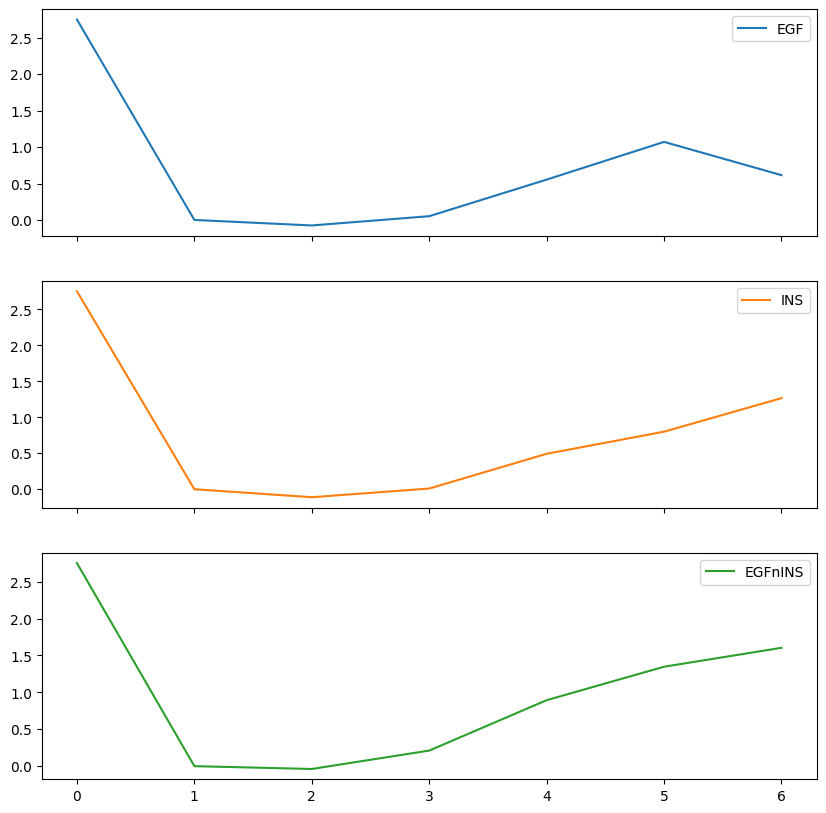

In [28]:
tsfresh_df[tsfresh_df['id'] == "A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR"].plot(subplots=True, sharex=True, figsize=(10,10))
plt.show()

In [31]:
from tsfresh import extract_features
tsfresh_df.fillna(0.0, inplace=True)
extracted_features = extract_features(tsfresh_df, column_id="id", column_sort="time")

Feature Extraction: 100%|██████████| 25/25 [00:56<00:00,  2.26s/it]


In [38]:
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

features = impute(extracted_features)
# features_filtered = select_features(extracted_features)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=81, random_state=42)
clusters = kmeans.fit_predict(features)

features['Clusters'] = clusters

# Step 5: See which cluster each sample belongs to
cluster_assignments = features[['Clusters']]
cluster_assignments

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,Clusters
A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,14
A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,76
A0AVK6_660_664_1_1_S664~ENSSALsPNHR,28
A0FGR8_736_748_1_1_S739~SSSsLLASPGHISVK,71
A0FGR8_736_748_1_1_S743~SSSSLLAsPGHISVK,53
...,...
Q9Y6X9_723_735_1_1_S725~KTEsPIKLSPATPSR,56
Q9Y6X9_723_735_2_2_S725S730~KTEsPIKLsPATPSR,39
Q9Y6X9_739_743_1_1_S743~SVAVsDEEEVEEEAERR,6
Q9Y6X9_739_743_2_2_S739S743~sVAVsDEEEVEEEAER,33


In [52]:
df["Clusters"] = clusters
df.to_excel("Experiment/1_hTERT_HME1/Results/Clusters/Cluster7/clustering_81.xlsx")

In [42]:
df["Clusters"] = cluster_assignments
for idx, row in cluster_assignments.iterrows():

7064